# Bias Analysis

This notebook assesses potential bias in NovaCred's past loan approval decisions. The analysis focused in differences in protected features (gender and age), intersectional effects (age × gender), and possible proxy discrimination through features such as ZIP code.

Fairness is measured using loan approval rate comparisons, Disparate Impact (four-fifths rule), Demographic Parity Difference, and chi-square statistical significance tests. The aim is to evaluate  whether observed approval outcomes show systemic disparities.

## Table of Contents

1. [Dataset Overview for Bias Analysis](#1-dataset-overview-for-bias-analysis)
   - 1.1 [Importing Necessary Libraries](#11-importing-necessary-libraries)
   - 1.2 [Dataset Loading](#12-dataset-loading)
   - 1.3 [Dataset Structure and Size](#13-dataset-structure-and-size)
   - 1.4 [Key Variables for the Analysis](#14-key-variables-for-the-analysis)
   - 1.5 [Missing Data Checks](#15-missing-data-checks)
2. [Gender Disparity Analysis](#2-gender-disparity-analysis)
   - 2.1 [Loan Approval Rates — Comparison](#21-loan-approval-rates--comparison)
   - 2.2 [Disparate Impact](#22-disparate-impact)
   - 2.3 [Demographic Parity Difference](#23-demographic-parity-difference)
   - 2.4 [Statistical Significance](#24-statistical-significance)
3. [Age Disparity Analysis](#3-age-disparity-analysis)
   - 3.1 [Loan Approval Rates — Comparison](#31-loan-approval-rates--comparison)
   - 3.2 [Disparate Impact](#32-disparate-impact)
   - 3.3 [Demographic Parity Difference](#33-demographic-parity-difference)
   - 3.4 [Statistical Significance](#34-statistical-significance)
4. [Age and Gender Interaction Analysis](#4-age-and-gender-interaction-analysis)
   - 4.1 [Loan Approval Rates by Age and Gender](#41-loan-approval-rates-by-age-and-gender)
   - 4.2 [Gender Disparate Impact within Age Groups](#42-gender-disparate-impact-within-age-groups)
   - 4.3 [Demographic Parity Difference](#43-demographic-parity-difference)
   - 4.4 [Statistical Significance](#44-statistical-significance)
5. [Proxy Discrimination](#5-proxy-discrimination)
   - 5.1 [ZIP Code](#51-zip-code)
     - 5.1.1 [Geographic Approval Gaps](#511-geographic-approval-gaps)
     - 5.1.2 [States' Demographic Composition](#512-states-demographic-composition)
   - 5.2 [Financial Variables](#52-financial-variables)
     - 5.2.1 [Average Financial Variables by Gender](#521-average-financial-variables-by-gender)
     - 5.2.2 [Average Financial Variables by Age Group](#522-average-financial-variables-by-age-group)
     - 5.2.3 [Relationship Between Financial Variables and Loan Approval](#523-relationship-between-financial-variables-and-loan-approval)
     - 5.2.4 [Correlation Analysis](#524-correlation-analysis)
     - 5.2.5 [Logistic Regression Models](#525-logistic-regression-models)
     - 5.2.6 [Conclusion](#526-financial-variables-as-proxies---conclusion)
6. [Overall Conclusions](#6-overall-conclusions)

## 1. Dataset Overview for Bias Analysis

### 1.1 Importing Necessary Libraries

In [39]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from fairlearn.metrics import demographic_parity_difference
from datetime import datetime


### 1.2 Dataset Loading

In [2]:
df = pd.read_csv("../data/credit_applications_clean.csv")
df.head()

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,age
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15 00:00:00+00:00,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,23.0,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,22.0
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,51.0,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,31.0
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,41.0,0.21,37909,True,NaN,vacation,3.7,59000.0,34.0
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077.0,103000.0,70.0,0.35,0,True,NaN,NaN,4.3,34000.0,40.0
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15 00:00:00+00:00,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080.0,57000.0,14.0,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,24.0


### 1.3 Dataset Structure and Size

In [7]:
# Checking basic info and distributions
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               501 non-null    object 
 1   spending_behavior                 501 non-null    object 
 2   processing_timestamp              62 non-null     object 
 3   applicant_info.full_name          501 non-null    object 
 4   applicant_info.email              494 non-null    object 
 5   applicant_info.ssn                496 non-null    object 
 6   applicant_info.ip_address         496 non-null    object 
 7   applicant_info.gender             498 non-null    object 
 8   applicant_info.date_of_birth      496 non-null    object 
 9   applicant_info.zip_code           499 non-null    float64
 10  financials.annual_income          496 non-null    float64
 11  financials.credit_history_months  499 non-null    float64
 12  financia

,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.interest_rate,decision.approved_amount,age
count,499.000000,496.000000,499.000000,500.000000,501.000000,292.000000,292.000000,339.000000
mean,47735.408818,82732.727397,50.645291,0.242660,29520.489022,4.564726,47845.890411,38.952802
std,39521.627144,28123.590403,31.117029,0.115888,16781.166700,1.162866,18103.754530,11.161701
min,10001.000000,0.000000,0.000000,0.050000,-5000.000000,2.500000,15000.000000,21.000000
25%,10048.000000,63000.000000,28.000000,0.150000,17289.000000,3.500000,34000.000000,30.500000
50%,10098.000000,81500.000000,49.000000,0.230000,27397.000000,4.550000,48000.000000,37.000000
75%,90244.000000,101250.000000,72.000000,0.342500,38281.000000,5.600000,62250.000000,45.000000
max,90299.000000,171000.000000,133.000000,0.450000,88078.000000,6.500000,80000.000000,65.000000


The bias analysis focuses on the following key variables:

- **decision.loan_approved** — binary outcome indicating whether the loan was approved.
- **applicant_info.gender** — gender of the applicant.
- **applicant_info.date_of_birth / applicant_info_age** — used to derive age and age groups.
- **applicant_info.zip_code** — geographic attribute evaluated as a potential proxy variable.
- **financial variables** (income, credit history, debt-to-income) — used to understand potential structural differences across groups.

### 1.5 Missing Data Checks

In [8]:
df.isna().sum()

_id                                   0
spending_behavior                     0
processing_timestamp                439
applicant_info.full_name              0
applicant_info.email                  7
applicant_info.ssn                    5
applicant_info.ip_address             5
applicant_info.gender                 3
applicant_info.date_of_birth          5
applicant_info.zip_code               2
financials.annual_income              5
financials.credit_history_months      2
financials.debt_to_income             1
financials.savings_balance            0
decision.loan_approved                0
decision.rejection_reason           292
loan_purpose                        451
decision.interest_rate              209
decision.approved_amount            209
age                                 162
dtype: int64

## 2. Gender Disparity Analysis

### 2.1 Loan Approval Rates - Comparison

Overall approval rate: 58.28%


,Rejected,Approved,Total,Approval Rate (%)
applicant_info.gender,,,,
Female,124,127,251,50.60
Male,84,163,247,65.99


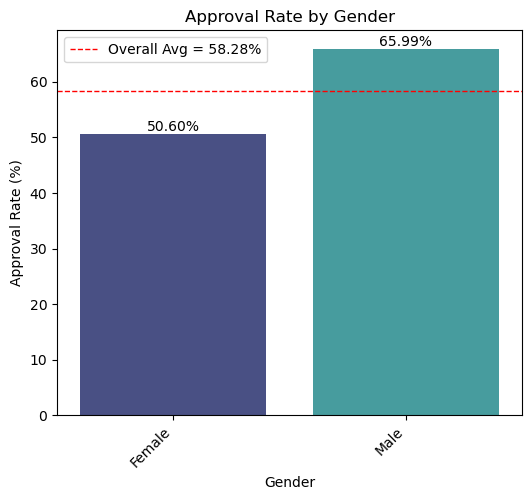

Difference in approval rates (Male − Female): 15.39 percentage points


In [44]:
# Calculate overall approval rate
overall_rate = df["decision.loan_approved"].mean()
overall_rate_percent = (overall_rate * 100).round(2).astype(str) + "%"

print("Overall approval rate:", overall_rate_percent)
# Approval summary by gender
gender_summary = pd.crosstab(
    df["applicant_info.gender"],
    df["decision.loan_approved"]
)

gender_summary.columns = ["Rejected", "Approved"]

# Add totals
gender_summary["Total"] = gender_summary["Rejected"] + gender_summary["Approved"]

# Add approval rate %
gender_summary["Approval Rate (%)"] = (
    gender_summary["Approved"] / gender_summary["Total"] * 100
).round(2)

display(gender_summary)

# Plotting 
plot_df = gender_summary.reset_index().rename(columns={"index": "applicant_info.gender"})

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=plot_df,
    x="applicant_info.gender",
    y="Approval Rate (%)",
    hue="applicant_info.gender",
    palette="mako",
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.axhline(
    overall_rate * 100,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Overall Avg = {overall_rate:.2%}"
)

plt.legend(loc="best")

plt.xticks(rotation=45, ha='right')
plt.title("Approval Rate by Gender")
plt.ylabel("Approval Rate (%)")
plt.xlabel("Gender")
plt.show()


female_rate = gender_summary.loc["Female", "Approval Rate (%)"]
male_rate = gender_summary.loc["Male", "Approval Rate (%)"]

rate_diff = male_rate - female_rate

print(f"Difference in approval rates (Male − Female): {rate_diff:.2f} percentage points")

- The loan approval rate for male candidates is 65.99%, whilst the approval rate for female applicants is 50.60%, a gap in loan acceptance between gender groups.
- The dataset also shows a nearly equal distribution of applications by gender (251 females vs. 247 males), indicating that sample imbalance is unlikely to be the cause of the discrepancy.

### 2.2 Disparate Impact

In [31]:
# Compute DI (privileged group = male)
female_rate = gender_summary.loc["Female", "Approval Rate (%)"] / 100
male_rate = gender_summary.loc["Male", "Approval Rate (%)"] / 100

disparate_impact = female_rate / male_rate


print(f"Male approval rate: {male_rate:.2%}")
print(f"Female approval rate: {female_rate:.2%}")
print(f"Disparate Impact (%): {disparate_impact*100:.2f}%")


Male approval rate: 65.99%
Female approval rate: 50.60%
Disparate Impact (%): 76.68%


- A DI below 80% indicates a possible negative impact on the underprivileged group (in this case, female candidates) according to the four-fifths rule. If below this threshold, it means that approval rates for women are less than 80% of that for men.
- Loan approval rates fall short of the four-fifths criteria (76.68% is less than 80%). This offers evidence of possible gender-based disparities in the approval process.

### 2.3 Demographic Parity Difference

In [154]:
group_rates = df.groupby("applicant_info.gender")["decision.loan_approved"].mean()
dpd_manual = group_rates.max() - group_rates.min()
print(f"Demographic Parity Difference: {dpd_manual*100:.2f}%")

Demographic Parity Difference: 15.39%


- The demographic parity difference is defined as the difference between the largest and the smallest group-level selection rate.
- A difference between the highest and lowest group-level selection rate up to 0.1 is often considered fair.
- The calculated DPD is 15.39% and this kind of discrepancy suggests that there may be a gender fairness concern.

### 2.4 Statistical Significance

In [43]:
# Creating contigency table 
table = pd.crosstab(df["applicant_info.gender"], df["decision.loan_approved"])

# perform chi-squared test
stat, p, dof, expected = stats.chi2_contingency(table)


# print results
print("Contingency table:")
print(table)

print(f"Chi-squared Statistic: {stat:.4f}")
print(f"Degrees of Freedom: {dof:.4f}")
print(f"P-value: {p:.4f}")

# interpret p-value
alpha = 0.05

if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')




Contingency table:
decision.loan_approved  False  True 
applicant_info.gender               
Female                    124    127
Male                       84    163
Chi-squared Statistic: 11.5053
Degrees of Freedom: 1.0000
P-value: 0.0007
Dependent (reject H0)


- To determine if approval results were statistically related to gender and significant, we employed a chi-square test of independence, where the null hypothesis (H0) is that loan approval is independent of gender.
- The results of the chi-square test of independence were:
    - χ²(1) = 11.50
    - p = 0.00069
- The findings suggest that gender and loan acceptance rates are statistically significantly associated, according to the chi-square test of independence (χ²(1) = 11.50, p < 0.05). This implies that random variation is unlikely to be the cause of the observed difference.

## 3. Age Disparity Analysis

### 3.1 Loan Approval Rates - Comparison

Minimum age in dataset: 21.0
Maximum age in dataset: 65.0


,Rejected,Approved,Total,Approval Rate (%)
age_group,,,,
"(21.0, 25.0]",21,13,34,38.24
"(25.0, 30.0]",27,23,50,46.00
"(30.0, 40.0]",53,68,121,56.20
"(40.0, 50.0]",21,51,72,70.83
"(50.0, 60.0]",18,26,44,59.09
"(60.0, 65.0]",5,12,17,70.59


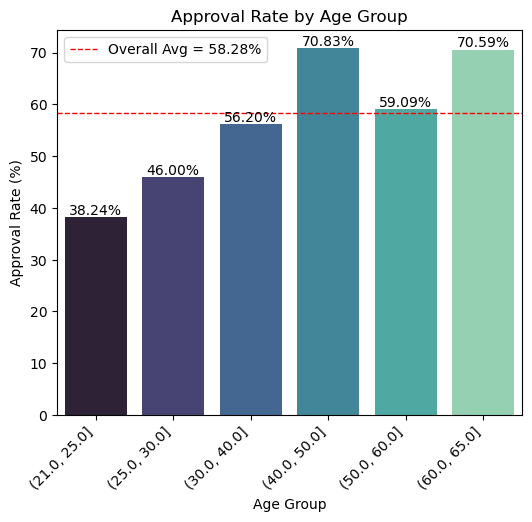

In [59]:
# minimum age
min_age = df["age"].min()
print(f"Minimum age in dataset: {min_age}")

# maximum age
max_age = df["age"].max()
print(f"Maximum age in dataset: {max_age}")

# Age buckets
df["age_group"] = pd.cut(df["age"], bins=[min_age, 25, 30, 40, 50, 60, max_age])

# Approval summary by age group
age_summary = pd.crosstab(
    df["age_group"],
    df["decision.loan_approved"]
)

age_summary.columns = ["Rejected", "Approved"]

# Add totals
age_summary["Total"] = age_summary["Rejected"] + age_summary["Approved"]

# Add approval rate %
age_summary["Approval Rate (%)"] = (
    age_summary["Approved"] / age_summary["Total"] * 100
).round(2)

display(age_summary)

# Plotting 
plot_df = age_summary.reset_index().rename(columns={"index": "age_group"})

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=plot_df,
    x="age_group",
    y="Approval Rate (%)",
    hue="age_group",
    palette="mako",
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.axhline(
    overall_rate * 100,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Overall Avg = {overall_rate:.2%}"
)

plt.legend(loc="best")

plt.xticks(rotation=45, ha='right')
plt.title("Approval Rate by Age Group")
plt.ylabel("Approval Rate (%)")
plt.xlabel("Age Group")
plt.show()


- The age distribution of applicants runs from 21 to 65 years old.
- Applicants aged 21-25 had the lowest approval rate of 38.24%, followed by those aged 25-30 with 46.00%. - Middle-aged candidates had higher approval rates, with 56.20% for the 30-40 group and 70.83% for the 40-50 group.
- Older applicants continue to have relatively high acceptance rates, with 59.09% for ages 50-60 and 70.59% for ages 60-65, despite the latter category having a lower sample size.Overall, the results imply that older applicants tend to have higher loan acceptance rates, whereas younger applicants suffer lower approval rates, indicating a possible age-related disparity in the approval process.

### 3.2 Disparate Impact

Because age has multiple categories/groups, we can't define a single “privileged group” as with gender. Instead, we calculated Disparate Impact by dividing the lowest approval rate by the highest approval rate. This way, we can measure how disadvantaged the worst-performing age group is relative to the best-performing one.

In [ ]:
# Compute approval rates by age group
age_rates = df.groupby("age_group", observed=True)["decision.loan_approved"].mean()

# Identify lowest and highest approval rates
min_rate = age_rates.min()
max_rate = age_rates.max()

# Identify least and most favored groups
least_favored_group = age_rates.idxmin()
most_favored_group = age_rates.idxmax()

# Compute Disparate Impact (least favored vs most favored)
disparate_impact_age = min_rate / max_rate

print(f"Least favored age group: {least_favored_group} ({min_rate:.2%})")
print(f"Most favored age group: {most_favored_group} ({max_rate:.2%})")

print(f"Age Disparate Impact (%): {disparate_impact_age*100:.2f}%")

Least favored age group: (21.0, 25.0] (38.24%)
Most favored age group: (40.0, 50.0] (70.83%)
Age Disparate Impact (%): 53.98%


- The least advantaged age group (21-25) receives approvals at only ~54% of the rate of the most advantaged group (40-50), which falls well below the four-fifths rule threshold and indicates potential age-based disparity.

### 3.3 Demographic Parity Difference

In [157]:
group_rates = df.groupby("age_group")["decision.loan_approved"].mean()
dpd_manual = group_rates.max() - group_rates.min()
print(f"Demographic Parity Difference: {dpd_manual*100:.2f}%")

Demographic Parity Difference: 32.60%


/var/folders/yd/zmymgz2s1s105pwr308yr3jw0000gn/T/ipykernel_87486/2804309944.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_rates = df.groupby("age_group")["decision.loan_approved"].mean()


- The difference identified in the previous section is confirmed by the Demographic Parity Difference of 22.13%, indicating a notable (despite not too large) disparity between age groups.

### 3.4 Statistical Significance

In [66]:
# Creating contigency table 
table = pd.crosstab(df["age_group"], df["decision.loan_approved"])

# perform chi-squared test
stat, p, dof, expected = stats.chi2_contingency(table)


# print results
print("Contingency table:")
print(table)

print(f"Chi-squared Statistic: {stat:.4f}")
print(f"Degrees of Freedom: {dof:.4f}")
print(f"P-value: {p:.4f}")

# interpret p-value
alpha = 0.05

if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')


Contingency table:
decision.loan_approved  False  True 
age_group                           
(21.0, 25.0]               21     13
(25.0, 30.0]               27     23
(30.0, 40.0]               53     68
(40.0, 50.0]               21     51
(50.0, 60.0]               18     26
(60.0, 65.0]                5     12
Chi-squared Statistic: 14.3720
Degrees of Freedom: 5.0000
P-value: 0.0134
Dependent (reject H0)



- To determine if approval results were statistically related to age and significant, we employed a chi-square test of independence, where the null hypothesis (H0) is that loan approval is independent of age.
- The results of the chi-square test of independence were:
    - χ²(5) = 14.37
    - p = 0.0134
- The findings suggest that age and loan acceptance rates are statistically significantly associated, according to the chi-square test of independence (χ²(5) = 14.37, p < 0.05). This implies that random variation is unlikely to be the cause of the observed difference.

## 4. Age and Gender Interaction Analysis

### 4.1 Loan Approval Rates by Age and Gender

In [72]:
# Counts (N)
interaction_counts = pd.crosstab(df["age_group"], df["applicant_info.gender"])

# Approval rates (as %)
interaction_rates = pd.crosstab(
    df["age_group"],
    df["applicant_info.gender"],
    values=df["decision.loan_approved"],
    aggfunc="mean"
) * 100

counts = interaction_counts[["Female", "Male"]]
rates  = interaction_rates[["Female", "Male"]].round(2)

# Build table with counts, rates, and gaps
summary = pd.DataFrame(index=counts.index)

summary["N (Female)"] = counts["Female"]
summary["N (Male)"]   = counts["Male"]
summary["N (Total)"]  = counts.sum(axis=1)

summary["Approval % (Female)"] = rates["Female"]
summary["Approval % (Male)"]   = rates["Male"]

summary["Gap (Male − Female) (pp)"] = (summary["Approval % (Male)"] - summary["Approval % (Female)"]).round(2)
display(summary)

,N (Female),N (Male),N (Total),Approval % (Female),Approval % (Male),Gap (Male − Female) (pp)
age_group,,,,,,
"(21.0, 25.0]",20,14,34,35.00,42.86,7.86
"(25.0, 30.0]",28,22,50,35.71,59.09,23.38
"(30.0, 40.0]",56,65,121,53.57,58.46,4.89
"(40.0, 50.0]",33,39,72,63.64,76.92,13.28
"(50.0, 60.0]",24,19,43,50.00,68.42,18.42
"(60.0, 65.0]",9,8,17,66.67,75.00,8.33


- The intersectional analysis of age and gender shows that male applicants have higher loan approval rates than female applicants in every age group.
- The largest disparity occurs in the 25–30 age group, where approval rates are 59.09% for males and 35.71% for females, a gap of 23.38 percentage points.
- Similarly large gaps appear in the 50–60 age group (18.42 percentage points) and 40–50 age group (13.28 percentage points).
- In contrast, the 30–40 age group shows a smaller difference of 4.89 percentage points, suggesting more similar approval outcomes between genders in that range.

###  4.2 Gender Disparate Impact within Age Groups

In [73]:
import numpy as np

di_interaction = interaction_rates.copy()

# Disparate impact per age group (female/male)
di_interaction["DI (Female/Male)"] = (di_interaction["Female"] / di_interaction["Male"]).round(3)
di_interaction["Fails 80% Rule"] = di_interaction["DI (Female/Male)"] < 0.8

display(di_interaction)

applicant_info.gender,Female,Male,DI (Female/Male),Fails 80% Rule
age_group,,,,
"(21.0, 25.0]",35.000000,42.857143,0.817,False
"(25.0, 30.0]",35.714286,59.090909,0.604,True
"(30.0, 40.0]",53.571429,58.461538,0.916,False
"(40.0, 50.0]",63.636364,76.923077,0.827,False
"(50.0, 60.0]",50.000000,68.421053,0.731,True
"(60.0, 65.0]",66.666667,75.000000,0.889,False


- According to the four-fifths rule, a disparate impact ratio below 0.80 suggests potential adverse impact on the disadvantaged group. 
- The results indicate that this threshold is violated in two age groups: 25–30, where the DI is 0.604, and 50–60, where the DI is 0.731 (meaning female applicants in these groups receive approvals at substantially lower rates than males).
- In the remaining age groups, the DI ratios range from 0.817 to 0.916, which are above the 0.80 threshold but still indicate moderate disparities favoring male applicants.

### 4.3 Demographic Parity Difference

In [159]:
from fairlearn.metrics import demographic_parity_difference

# Create intersection group (age × gender)
df_intersection = df[
    df["applicant_info.gender"].isin(["Male", "Female"])
].dropna(subset=["age_group"]).copy()

df_intersection["age_gender_group"] = (
    df_intersection["age_group"].astype(str) + "_" +
    df_intersection["applicant_info.gender"].astype(str)
)

# Compute approval rate per intersection group
intersection_rates = (
    df_intersection
    .groupby("age_gender_group", observed=True)["decision.loan_approved"]
    .mean()
)

display((intersection_rates * 100).round(2))

# Identify extreme groups
most_advantaged = intersection_rates.idxmax()
least_advantaged = intersection_rates.idxmin()

most_rate = intersection_rates.max()
least_rate = intersection_rates.min()

print(f"Most advantaged group: {most_advantaged} ({most_rate*100:.2f}%)")
print(f"Least advantaged group: {least_advantaged} ({least_rate*100:.2f}%)")

# Compute Demographic Parity Difference across intersection groups

group_rates = df_intersection.groupby("age_gender_group", observed=True)["decision.loan_approved"].mean()
dpd_manual = group_rates.max() - group_rates.min()
print(f"Intersectional Demographic Parity Difference: {dpd_manual*100:.2f}%")

age_gender_group
(21.0, 25.0]_Female    35.00
(21.0, 25.0]_Male      42.86
(25.0, 30.0]_Female    35.71
(25.0, 30.0]_Male      59.09
(30.0, 40.0]_Female    53.57
(30.0, 40.0]_Male      58.46
(40.0, 50.0]_Female    63.64
(40.0, 50.0]_Male      76.92
(50.0, 60.0]_Female    50.00
(50.0, 60.0]_Male      68.42
(60.0, 65.0]_Female    66.67
(60.0, 65.0]_Male      75.00
Name: decision.loan_approved, dtype: float64

Most advantaged group: (40.0, 50.0]_Male (76.92%)
Least advantaged group: (21.0, 25.0]_Female (35.00%)
Intersectional Demographic Parity Difference: 41.92%


- Male applicants aged 40-50 have the highest approval rate, at 76.92%, while female candidates aged 21-25 have the lowest approval rate, at 35.0%. - This substantial imbalance leads in an intersectional demographic parity difference of 41.92 percentage points.
- The findings indicate that younger female candidates had the lowest approval probability, whilst middle-aged male applicants have substantially higher acceptance rates.
- Overall, this intersectional pattern suggests that both age and gender impact approval outcomes, and the combined effect results in a greater gap than when each attribute is analyzed independently.

### 4.4 Statistical Significance

In [78]:
# Creating contigency table 
table = pd.crosstab(df_intersection["age_gender_group"], df_intersection["decision.loan_approved"])

# perform chi-squared test
stat, p, dof, expected = stats.chi2_contingency(table)


# print results
print("Contingency table:")
print(table)

print(f"Chi-squared Statistic: {stat:.4f}")
print(f"Degrees of Freedom: {dof:.4f}")
print(f"P-value: {p:.4f}")

# interpret p-value
alpha = 0.05

if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')


Contingency table:
decision.loan_approved  False  True 
age_gender_group                    
(21.0, 25.0]_Female        13      7
(21.0, 25.0]_Male           8      6
(25.0, 30.0]_Female        18     10
(25.0, 30.0]_Male           9     13
(30.0, 40.0]_Female        26     30
(30.0, 40.0]_Male          27     38
(40.0, 50.0]_Female        12     21
(40.0, 50.0]_Male           9     30
(50.0, 60.0]_Female        12     12
(50.0, 60.0]_Male           6     13
(60.0, 65.0]_Female         3      6
(60.0, 65.0]_Male           2      6
Chi-squared Statistic: 20.4296
Degrees of Freedom: 11.0000
P-value: 0.0398
Dependent (reject H0)


- To determine if approval results were statistically associated with the combined effect of age and gender, we employed a chi-square test of independence, where the null hypothesis (H0) is that loan approval is independent of this intersection.
- The results of the chi-square test of independence were:
    - χ²(11) = 20.43
    - p = 0.0398
- The findings suggest that gender, age and loan acceptance rates are statistically significantly associated, according to the chi-square test of independence (χ²(11) = 20.43, p < 0.05). This implies that random variation is unlikely to be the cause of the observed difference.

## 5. Proxy Discrimination

Proxy discrimination occurs when neutral features (such as ZIP code, spending patterns, or income) are used to indirectly discriminate against protected groups (e.g., race, gender), even if the protected attributes themselves are not used directly in decision-making. 

This section investigates whether certain financial or geographic variables in the dataset may act as proxies for protected attributes. Specifically, we examine whether these variables are associated with gender or age and whether they are also associated with loan approval outcomes.

### 5.1 ZIP Code

We assess whether ZIP codes act as discriminative proxy by analysing both **Geographic Approval Gaps** (Do applicants in across states receive varied acceptance rates?) and **States' Demographic Composition** (Is the geographical approval difference explained by a gender imbalance between sttaes, or does ZIP code serve as a proxy for gender?).

#### 5.1.1 Geographic Approval Gaps

In [104]:
# Approval rates by ZIP code
zip_summary = (
    df.groupby("applicant_info.zip_code")["decision.loan_approved"]
    .agg(N="count", Approval_Rate="mean")
    .sort_values("N", ascending=False)
)

zip_summary["Approval_Rate (%)"] = (zip_summary["Approval_Rate"] * 100).round(2)


display(zip_summary[["N", "Approval_Rate (%)"]].head(15))

,N,Approval_Rate (%)
applicant_info.zip_code,,
10048.0,8,75.00
10096.0,7,28.57
90284.0,7,42.86
10019.0,6,33.33
10004.0,6,100.00
10020.0,6,66.67
10057.0,6,50.00
90205.0,5,20.00
10041.0,5,60.00


,N,approved,approval_rate
state,,,
Los Angeles (CA),230,119,51.74
New York (NY),251,162,64.54
Other,18,10,55.56


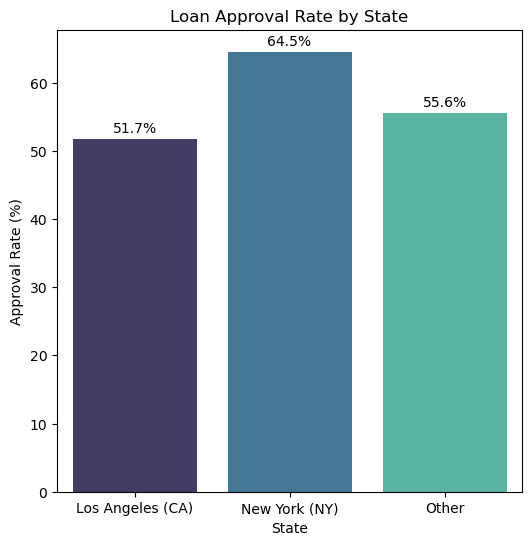

In [105]:
# Map ZIP prefix to US state (10xxx codes are New York and 90xxx are California/Los Angeles)
def zip_to_state(zip_code):
    if pd.isna(zip_code):
        return pd.NA
    prefix = str(int(zip_code))[:2]
    state_map = {
        "10": "New York (NY)",
        "90": "Los Angeles (CA)"
    }
    return state_map.get(prefix, "Other")

df["state"] = df["applicant_info.zip_code"].apply(zip_to_state)

# approval rate by state
state_summary = (
    df.groupby("state")["decision.loan_approved"]
    .agg(N="count", approved="sum")
    .assign(approval_rate=lambda x: (x["approved"] / x["N"] * 100).round(2))
)

display(state_summary)

# Plot
plt.figure(figsize=(6,6))

ax = sns.barplot(
    data=state_summary,
    x="state",
    y="approval_rate",
    palette="mako",
    hue="state"
)

# Add labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

plt.title("Loan Approval Rate by State")
plt.xlabel("State")
plt.ylabel("Approval Rate (%)")

plt.show()

- New York applicants are approved at 64.54% vs 51.74% in LA, a 12.8 percentage point gap. 

#### 5.1.2 States' Demographic Composition

In [160]:
# Gender composition by region
ct_state_gender_counts = pd.crosstab(
    df["state"],
    df["applicant_info.gender"]
)

ct_state_gender_pct = ct_state_gender_counts.div(
    ct_state_gender_counts.sum(axis=1), axis=0
).round(4)

display(ct_state_gender_pct)


applicant_info.gender,Female,Male
state,,
Los Angeles (CA),0.9348,0.0652
New York (NY),0.1120,0.8880
Other,0.4444,0.5556


- The table reveals that applicants from Los Angeles (CA) are mostly female (93.48% female vs. 6.52% male), whereas applicants from New York (NY) are primarily male (88.80% male vs. 11.20% female). The "Other" group has a more balanced proportion (44.44% female, 55.56% male).

In [119]:
# perform chi-squared test
stat, p, dof, expected = stats.chi2_contingency(ct_state_gender_counts)

# print results
print("Contingency table (raw counts):")
print(ct_state_gender_counts)

print(f"\nChi-squared Statistic: {stat:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p}")

# interpret p-value
alpha = 0.05

if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

Contingency table (raw counts):
applicant_info.gender  Female  Male
region                             
Los Angeles (CA)          215    15
New York (NY)              28   222
Other                       8    10

Chi-squared Statistic: 324.6681
Degrees of Freedom: 2
P-value: 3.1566142531131733e-71
Dependent (reject H0)


- The chi-square test of independence reveals a statistically significant difference, with a chi-squared score of 324.67, 2 degrees of freedom, and an exceptionally small p-value (≈ 3.16 × 10⁻⁷¹). Because the p-value is significantly lower than the 0.05 threshold, the null hypothesis that gender and state are independent is rejected.
- As a result, location (state) may serve as a proxy variable, implying that geographic characteristics may indirectly reproduce gender discrepancies in loan acceptance decisions if they impact the model or decision process.

### 5.2 Financial Variables

Income, credit history, debt-to-income ratio, and savings balance are all examples of neutral credit score criteria. However, if these factors are systematically distributed differentially across gender or age groups and predict approval results at the same time, they may serve as proxy variables.

We used four financial variables: 
- `financials.annual_income`
- `financials.credit_history_months`
- `financials.debt_to_income`
- `financials.savings_balance`

Our analysis will be based in understanding whether financial variables' distribution is significantly associated with gender and/or age groups and whether financial variables' are significantly associated with loan approval.

#### 5.2.1 Average Financial Variables by Gender

In [136]:
financial_vars = [
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance"
]

cols = financial_vars + ["decision.loan_approved"]

gender_financial_summary = (
    df.groupby("applicant_info.gender")[cols]
    .mean()
    .round(2)
)

display(gender_financial_summary)

,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved
applicant_info.gender,,,,,
Female,83912.68,51.43,0.24,29414.61,0.51
Male,81439.02,49.78,0.25,29659.85,0.66


- Females earn somewhat more on average (€83k vs €81k), have a little longer credit history, and about similar Debt-to-income Ratio and savings.
- This analysis shows that financial variables do not explain the gender approval difference. Women are rejected at greater rates than Men, despite having similar or somewhat superior financial backgrounds. This supports the case for direct gender prejudice over proxy discrimination through financials.

#### 5.2.2 Average Financial Variables by Age Group

In [137]:
age_financial_summary = (
    df.groupby("age_group")[cols]
    .mean()
    .round(2)
)

display(age_financial_summary)

/var/folders/yd/zmymgz2s1s105pwr308yr3jw0000gn/T/ipykernel_87486/4026904768.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")[cols]


,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved
age_group,,,,,
"(21.0, 25.0]",46619.18,27.42,0.24,17249.18,0.38
"(25.0, 30.0]",63640.00,32.18,0.25,20963.26,0.46
"(30.0, 40.0]",89148.76,38.85,0.26,31885.79,0.56
"(40.0, 50.0]",96671.43,64.67,0.25,33985.29,0.71
"(50.0, 60.0]",84767.44,82.48,0.21,31508.07,0.59
"(60.0, 65.0]",95941.18,95.65,0.23,35096.06,0.71


- There is a clear trend across all variables: younger candidates face structural disadvantages. 
- The 21-25 age group earns roughly half as much as the 60-65 age group (€46k vs €95k), has a far shorter credit history (27 vs 95 months), and saves less. This is expected as it indicates life stages. 
- Using credit history and savings balance as a loan approval factor will automatically disfavor young candidates, regardless of their real risk level.

#### 5.2.3 Relationship Between Financial Variables and Loan Approval


In [138]:
# Relationship Between Financial Variables and Loan Approval
approval_financial_summary = (
    df.groupby("decision.loan_approved")[financial_vars]
    .mean()
    .round(2)
)

display(approval_financial_summary)

,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance
decision.loan_approved,,,,
False,76695.65,45.44,0.24,26887.03
True,87056.86,54.37,0.24,31405.40


- Approved applicants had a greater income (€87k vs €77k), a longer credit history (54 vs 45 months), and larger savings (€31k vs €27k). Debt-to-income ratio equals 0.24.
- The income and credit history gaps indicate that these criteria affect approval, but many rejected applicants have high incomes, suggesting that financial indicators alone do not determine approval decisions.

#### 5.2.4 Correlation Analysis

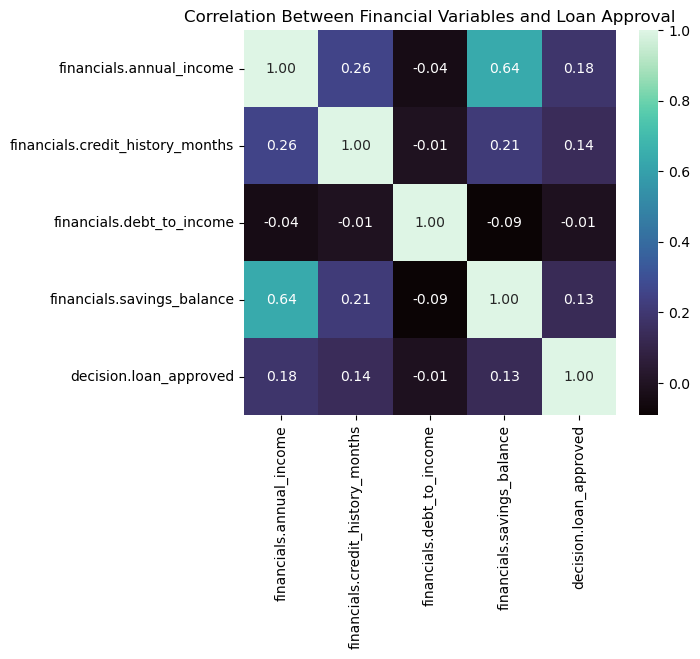

In [139]:
# Correlation Analysis
corr_data = df[financial_vars + ["decision.loan_approved"]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_data,
    annot=True,
    cmap="mako",
    fmt=".2f"
)

plt.title("Correlation Between Financial Variables and Loan Approval")

plt.show()

- Loan approval has a positive correlation with income (0.18), credit history (0.14), and savings amount (0.13). These correlations are weak but positive and suggest that stronger financial indicators lead to higher approval rates.
- Debt-to-income ratio has essentially little correlation with loan approval, indicating that it has low predictive power in this sample.

#### 5.2.5 Logistic Regression Models

In [151]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

cols_needed = [
    "applicant_info.gender",
    "age_group",
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
    "decision.loan_approved"
]

df_reg = (
    df[df["applicant_info.gender"].isin(["Male", "Female"])]
    .dropna(subset=cols_needed)
    .copy()
)

# Encode gender: female = 0, male = 1
df_reg["gender_encoded"] = (df_reg["applicant_info.gender"] == "Male").astype(int)

# Encode age group as ordinal integer
age_order = {str(g): i for i, g in enumerate(sorted(df_reg["age_group"].unique()))}
df_reg["age_encoded"] = df_reg["age_group"].astype(str).map(age_order)

y = df_reg["decision.loan_approved"].astype(int)

financial_cols = [
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
]

# Model A: demographics only
features_A = ["gender_encoded", "age_encoded"]
X_A = StandardScaler().fit_transform(df_reg[features_A])
model_A = LogisticRegression(max_iter=1000)
model_A.fit(X_A, y)

# Model B: demographics + financial controls
features_B = ["gender_encoded", "age_encoded"] + financial_cols
X_B = StandardScaler().fit_transform(df_reg[features_B])
model_B = LogisticRegression(max_iter=1000)
model_B.fit(X_B, y)

# Comparison table
or_A = dict(zip(features_A, np.exp(model_A.coef_[0]).round(4)))
or_B = dict(zip(features_B, np.exp(model_B.coef_[0]).round(4)))

comparison = pd.DataFrame({
    "Feature": features_B,
    "OR — Model A (demographics only)": [or_A.get(f, "—") for f in features_B],
    "OR — Model B (with financials)":   [round(or_B[f], 4) for f in features_B],
})

print(f"Model A accuracy: {model_A.score(X_A, y)*100:.1f}%")
print(f"Model B accuracy: {model_B.score(X_B, y)*100:.1f}%\n")
display(comparison)

Model A accuracy: 60.3%
Model B accuracy: 63.0%



,Feature,OR — Model A (demographics only),OR — Model B (with financials)
0,gender_encoded,1.2904,1.3091
1,age_encoded,1.399,1.0312
2,financials.annual_income,—,1.4535
3,financials.credit_history_months,—,1.3099
4,financials.debt_to_income,—,1.0937
5,financials.savings_balance,—,0.9465


- **Gender:**  The odds ratio for 'gender_encoded' remains identical between Model A and Model B (1.29 → 1.31), indicating that financial variables do not explain the gender disparity. After adjusting for income, credit history, debt-to-income ratio, and savings, males had a 31% higher approval rate.

- **Age:** Adding financial variables to the model reduces the odds ratio for 'age_encoded' from 1.40 to 1.03, indicating a significant collapse. This confirms that age prejudice occurs through proxy discrimination, with younger applicants facing disadvantages, rather than age itself.

| | Model A | Model B | Change | Interpretation |
|---|---|---|---|---|
| gender_encoded | 1.29 | 1.31 | +0.02 | No change — direct bias |
| age_encoded | 1.40 | 1.03 | -0.37 | Collapses — proxy bias |

#### 5.2.6 Conclusion


The analysis of financial variables reveals a split picture depending on which protected attribute is examined.

- **For gender**, the data suggests direct bias rather than proxy discrimination. Female applicants had equivalent or somewhat stronger financial profiles than male applicants yet face significantly lower approval rates. Because financial indicators do not change significantly across gender, they cannot explain the approval discrepancy.

- **For age**, the data suggests structural proxy discrimination. Younger applicants have systematic disadvantages across all financial variables (lower income, shorter credit history, and poorer savings) but this is due to life stages rather than creditworthiness. Credit history, in particular, functions as a near-perfect age proxy.

- **The correlation analysis reinforces both conclusions.** All financial factors have modest correlations with loan approval (≤ 0.18), indicating that financial indicators explain only a small portion of approval decisions. The insufficient strength of these relationships, combined with the significant gender and age approval gaps identified in previous sections, suggests that the approval algorithm is weighting factors other than financial risk.

- When financial controls are applied, the gender odds ratio remains nearly identical (1.29 → 1.31), demonstrated by the **Logistic Regression Model**. Male approval advantage is direct and independent of financial disparities. The age odds ratio falls from 1.40 to 1.03, indicating that age bias is influenced by financial characteristics.


## 6. Final Bias Assessment